# Notebook 06 — Pipeline Results Validation
## Sentinel-2 Brownfield Site Detection — SiteSignal Ltd

This notebook documents the results of the first full end-to-end Version 2 pipeline run for Stoke-on-Trent, using the Sentinel-2 L2A image captured on 25 May 2026. It validates the 218 candidate sites produced by the clustering module against the brownfield register, examines the geographic distribution of matched and unmatched sites, interprets the change detection findings, and discusses the implications for Version 3 development.

All results in this notebook were produced by running `python src/main.py --gss_code E06000021 --date 2026-05-25` with BSI>0.1, NDVI<0.2, min_pixels=10, max_pixels=2500.

In [15]:
%matplotlib inline
import sys
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.database_query import get_db_connection, retrieve_brownfield_register_data, detect_register_changes
import psycopg2

conn = get_db_connection()

# Retrieve candidate sites from database
cursor = conn.cursor()
cursor.execute("""
    SELECT utm_x, utm_y, pixel_count, bsi_value, matched_site_reference
    FROM candidate_sites
    WHERE gss_code = 'E06000021'
    AND run_timestamp = (
        SELECT MAX(run_timestamp) FROM candidate_sites WHERE gss_code = 'E06000021'
    )
    ORDER BY bsi_value DESC
""")
candidate_sites = cursor.fetchall()
cursor.close()

print(f"Candidate sites retrieved from database: {len(candidate_sites)}")

matched = [s for s in candidate_sites if s[4] is not None]
unmatched = [s for s in candidate_sites if s[4] is None]

print(f"Matched to register: {len(matched)}")
print(f"Unregistered candidates: {len(unmatched)}")
print(f"Match rate: {len(matched)/len(candidate_sites)*100:.1f}%")

Candidate sites retrieved from database: 218
Matched to register: 39
Unregistered candidates: 179
Match rate: 17.9%


## Section 1 — Pipeline Run Summary

The Version 2 pipeline ran successfully end-to-end for Stoke-on-Trent using the Sentinel-2 L2A image captured on 25 May 2026. Key results:

- **218 candidate sites** identified by the BSI/NDVI threshold clustering algorithm
- **39 sites (17.9%) matched** to entries on the Stoke-on-Trent brownfield register
- **179 sites (82.1%) unregistered** — potential brownfield land not appearing on the current register

The 17.9% match rate is lower than might initially be expected. As established in Notebooks 04 and 05, this is explained by the nature of the detection approach: BSI>0.1 and NDVI<0.2 detects currently **bare** land only. The 2024 Stoke register contains 218 sites with a mean NDVI of 0.21 — meaning most registered sites are vegetated at the time of this image and are therefore invisible to the threshold detector.

The 39 matched sites are registered brownfield sites that happen to be currently bare — cleared, disturbed, or under active remediation at the time of the May 2026 image. The 179 unmatched sites are the primary finding: land that is currently bare, spectral signatures consistent with brownfield, and not appearing on any register.

Section 2 — Candidate Site Size and BSI Distribution
All sites:
  Size: min 0.40ha, max 6.80ha, mean 0.76ha
  BSI: min -0.0290, max 0.1723, mean 0.0593

Matched sites (39):
  Size: min 0.40ha, max 3.12ha, mean 0.75ha
  BSI: min -0.0155, max 0.0905, mean 0.0587

Unregistered candidates (179):
  Size: min 0.40ha, max 6.80ha, mean 0.76ha
  BSI: min -0.0290, max 0.1723, mean 0.0594


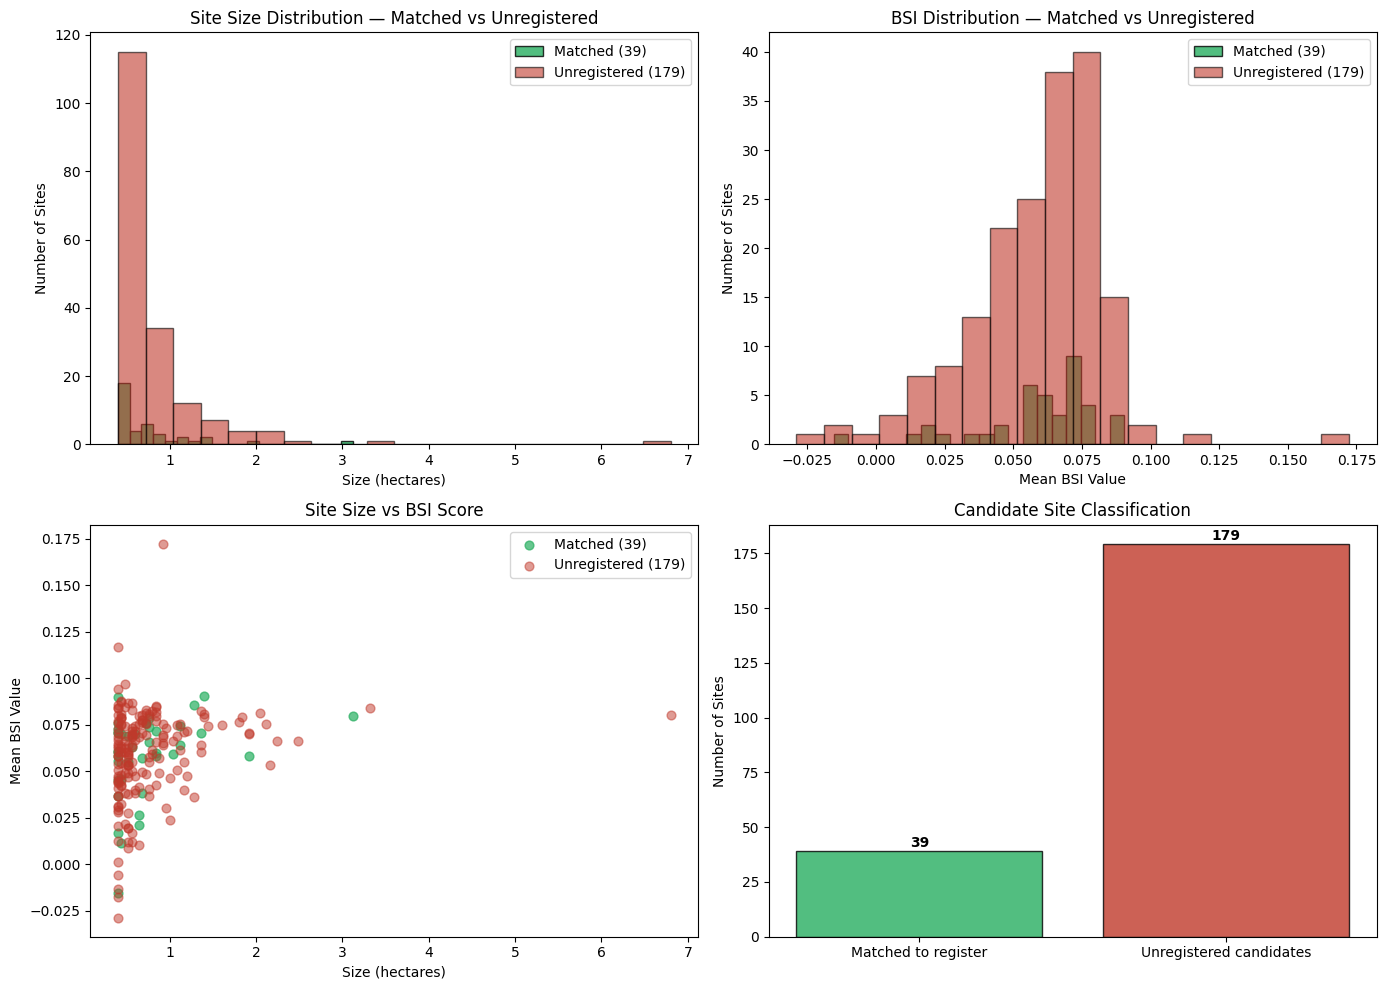

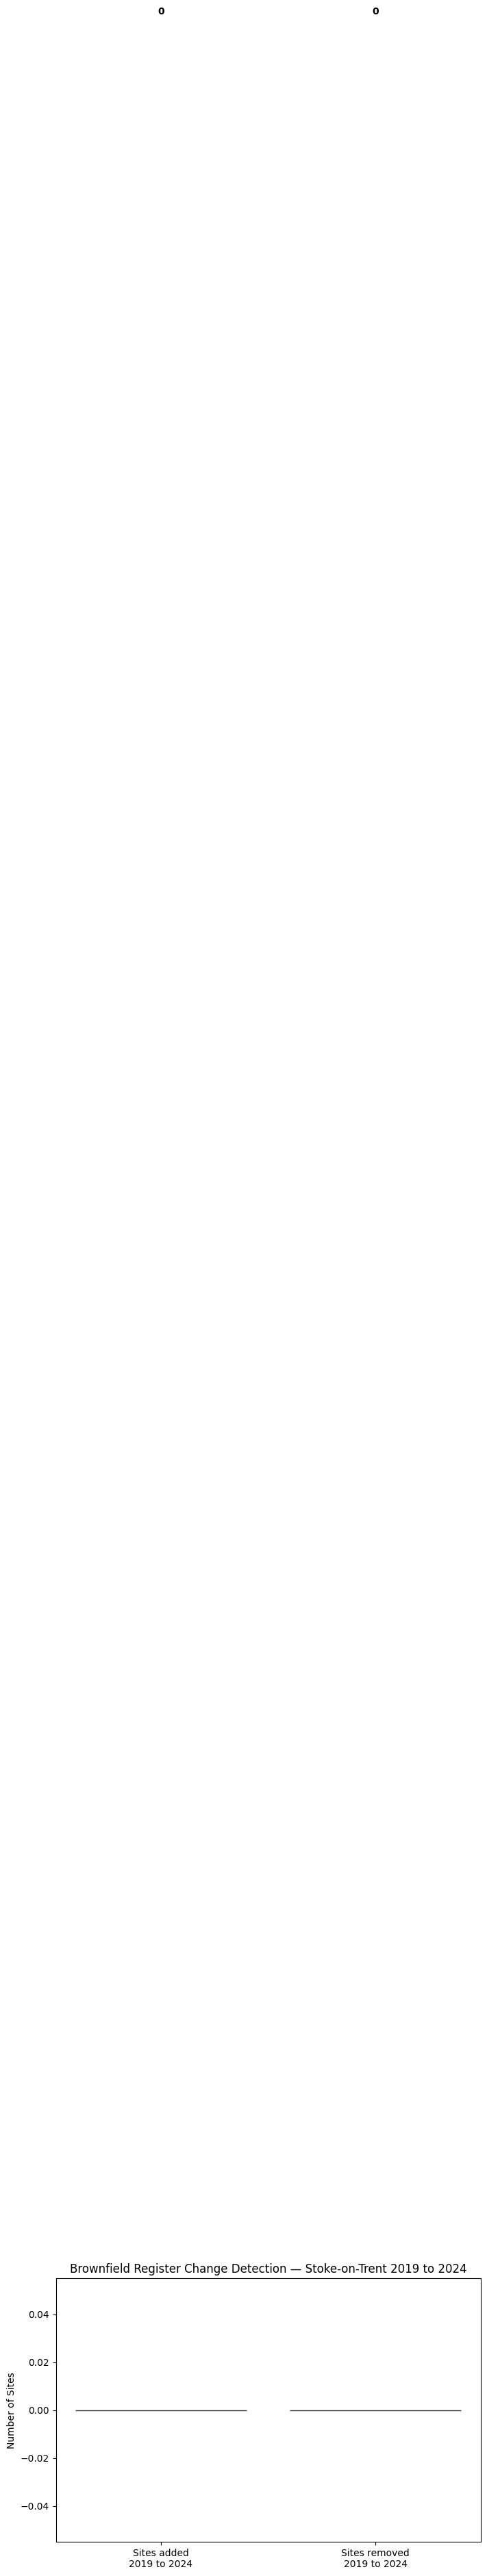

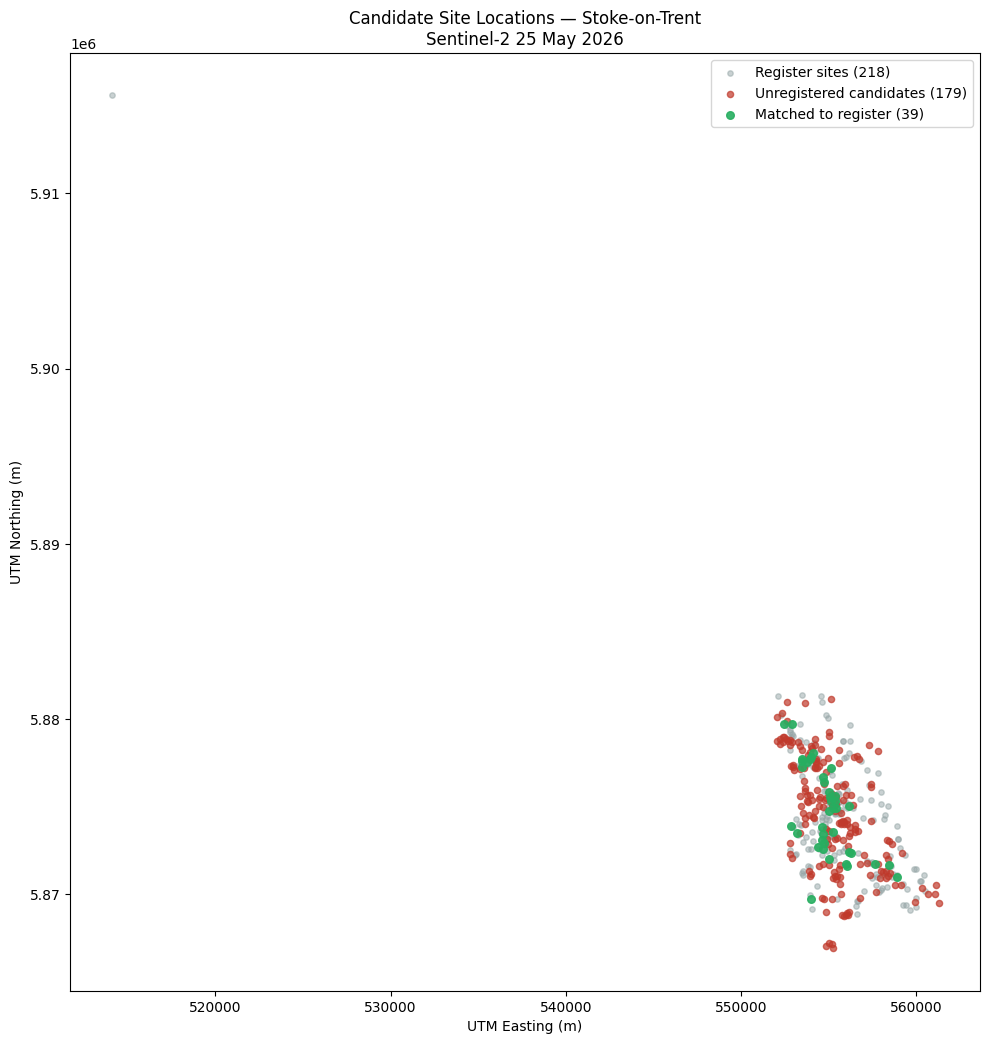

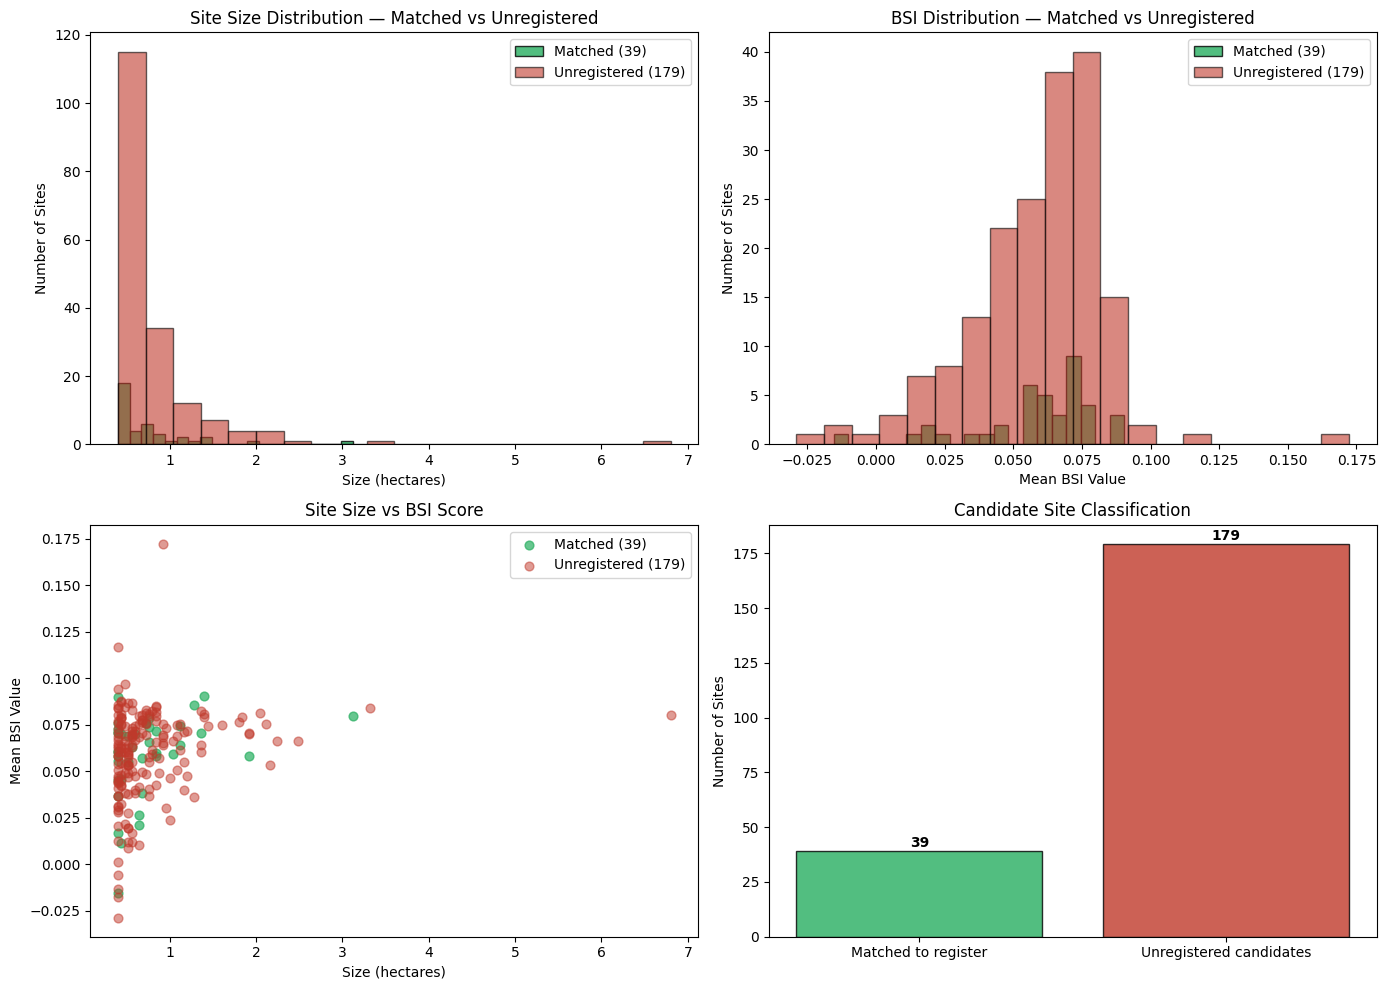

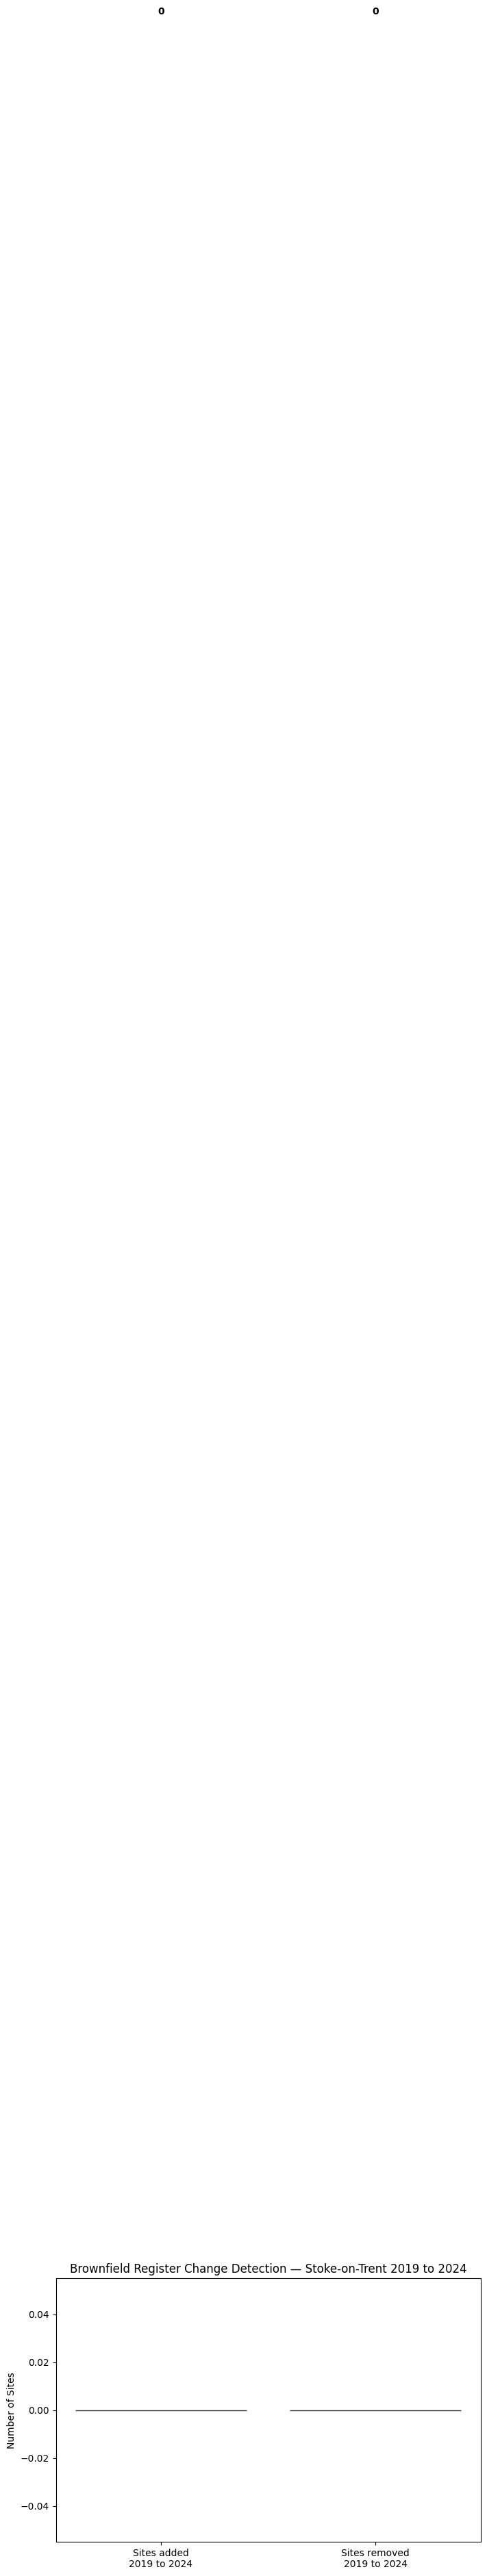

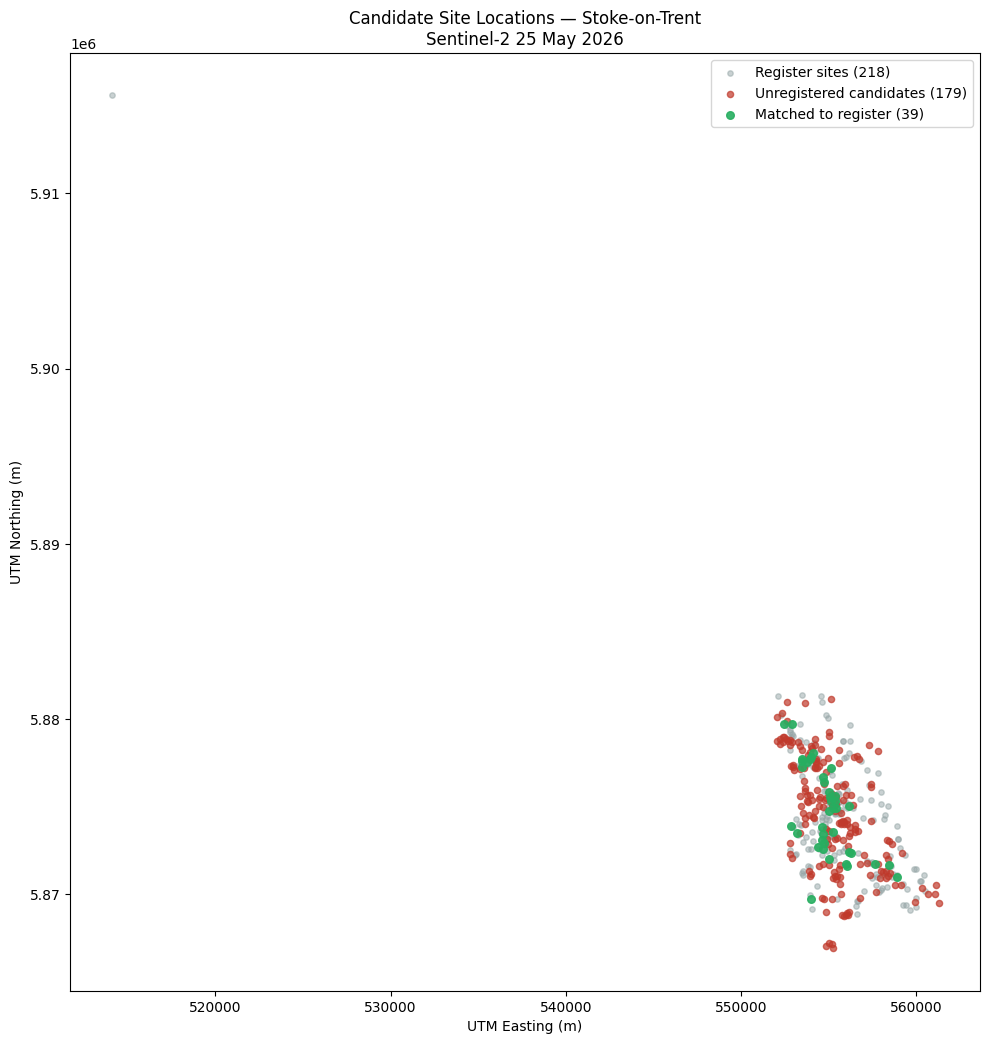

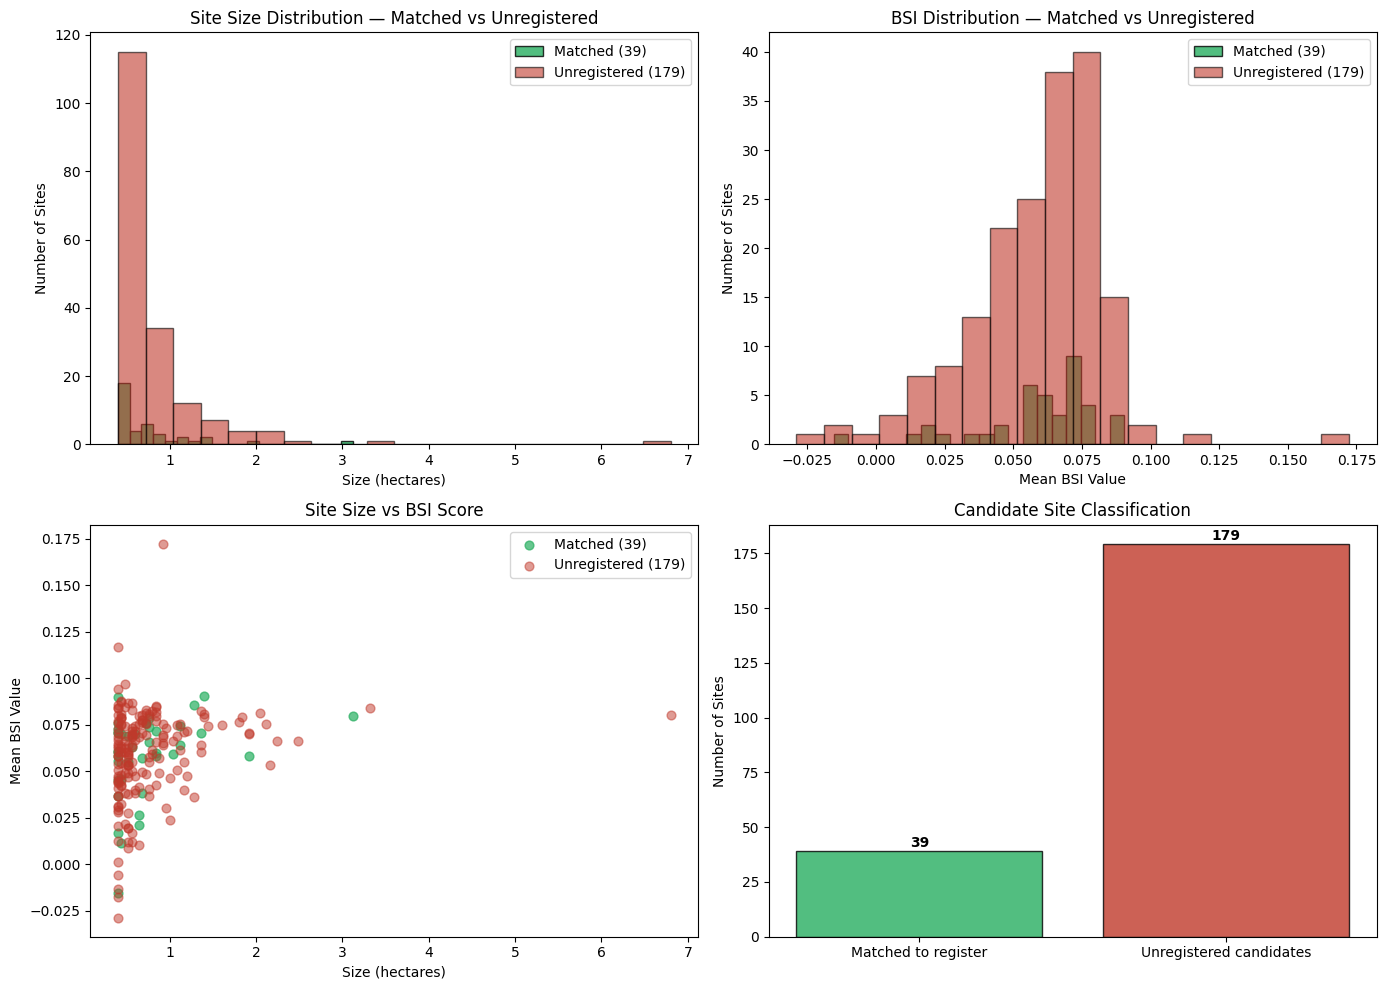

Saved to docs/images/pipeline_results_distribution.png


In [16]:
print("Section 2 — Candidate Site Size and BSI Distribution")
print("="*60)

pixel_counts = [s[2] for s in candidate_sites]
bsi_values = [s[3] for s in candidate_sites]
hectares = [p * 0.04 for p in pixel_counts]

matched_hectares = [s[2] * 0.04 for s in matched]
unmatched_hectares = [s[2] * 0.04 for s in unmatched]
matched_bsi = [s[3] for s in matched]
unmatched_bsi = [s[3] for s in unmatched]

print(f"All sites:")
print(f"  Size: min {min(hectares):.2f}ha, max {max(hectares):.2f}ha, mean {sum(hectares)/len(hectares):.2f}ha")
print(f"  BSI: min {min(bsi_values):.4f}, max {max(bsi_values):.4f}, mean {sum(bsi_values)/len(bsi_values):.4f}")

print(f"\nMatched sites (39):")
print(f"  Size: min {min(matched_hectares):.2f}ha, max {max(matched_hectares):.2f}ha, mean {sum(matched_hectares)/len(matched_hectares):.2f}ha")
print(f"  BSI: min {min(matched_bsi):.4f}, max {max(matched_bsi):.4f}, mean {sum(matched_bsi)/len(matched_bsi):.4f}")

print(f"\nUnregistered candidates (179):")
print(f"  Size: min {min(unmatched_hectares):.2f}ha, max {max(unmatched_hectares):.2f}ha, mean {sum(unmatched_hectares)/len(unmatched_hectares):.2f}ha")
print(f"  BSI: min {min(unmatched_bsi):.4f}, max {max(unmatched_bsi):.4f}, mean {sum(unmatched_bsi)/len(unmatched_bsi):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(matched_hectares, bins=20, color='#27ae60', edgecolor='black', alpha=0.8, label='Matched (39)')
axes[0, 0].hist(unmatched_hectares, bins=20, color='#c0392b', edgecolor='black', alpha=0.6, label='Unregistered (179)')
axes[0, 0].set_title('Site Size Distribution — Matched vs Unregistered')
axes[0, 0].set_xlabel('Size (hectares)')
axes[0, 0].set_ylabel('Number of Sites')
axes[0, 0].legend()

axes[0, 1].hist(matched_bsi, bins=20, color='#27ae60', edgecolor='black', alpha=0.8, label='Matched (39)')
axes[0, 1].hist(unmatched_bsi, bins=20, color='#c0392b', edgecolor='black', alpha=0.6, label='Unregistered (179)')
axes[0, 1].set_title('BSI Distribution — Matched vs Unregistered')
axes[0, 1].set_xlabel('Mean BSI Value')
axes[0, 1].set_ylabel('Number of Sites')
axes[0, 1].legend()

axes[1, 0].scatter(matched_hectares, matched_bsi, color='#27ae60', alpha=0.7, label='Matched (39)', s=40)
axes[1, 0].scatter(unmatched_hectares, unmatched_bsi, color='#c0392b', alpha=0.5, label='Unregistered (179)', s=40)
axes[1, 0].set_title('Site Size vs BSI Score')
axes[1, 0].set_xlabel('Size (hectares)')
axes[1, 0].set_ylabel('Mean BSI Value')
axes[1, 0].legend()

axes[1, 1].bar(['Matched to register', 'Unregistered candidates'],
               [len(matched), len(unmatched)],
               color=['#27ae60', '#c0392b'], edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Candidate Site Classification')
axes[1, 1].set_ylabel('Number of Sites')
for i, v in enumerate([len(matched), len(unmatched)]):
    axes[1, 1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/images/pipeline_results_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/images/pipeline_results_distribution.png")

## Section 2 — Candidate Site Characteristics

The size and BSI distributions reveal an important finding: **matched and unregistered candidate sites are spectrally and physically indistinguishable.**

- Matched sites: mean 0.75ha, mean BSI 0.0587
- Unregistered candidates: mean 0.76ha, mean BSI 0.0594

The distributions overlap almost completely — there is no meaningful spectral or size difference between sites that appear on the register and sites that do not. This has two implications:

**1. The detection is consistent:** The algorithm is not finding register sites through a different mechanism than unregistered candidates. Both groups are detected by the same BSI/NDVI threshold and are spectrally equivalent bare soil patches. This means the 179 unregistered candidates are genuinely comparable in character to the 39 known brownfield sites — not noise or false positives from a different land cover type.

**2. The register is incomplete by omission, not by spectral difference:** The 179 unregistered sites are not on the register because planners haven't identified them — not because they have different physical characteristics from registered sites. This is exactly the gap SiteSignal Ltd is designed to fill.

The maximum site size of 6.80ha for unregistered candidates versus 3.12ha for matched sites is worth noting — the largest unregistered candidates are bigger than the largest matched sites. If confirmed on the ground, a 6.80ha unregistered brownfield site would be a significant planning finding.

Section 3 — Change Detection Analysis
Sites added to register 2019 to 2024: 0
Sites removed from register 2019 to 2024: 0

Sites removed (likely developed):

First 10 sites added since 2019:


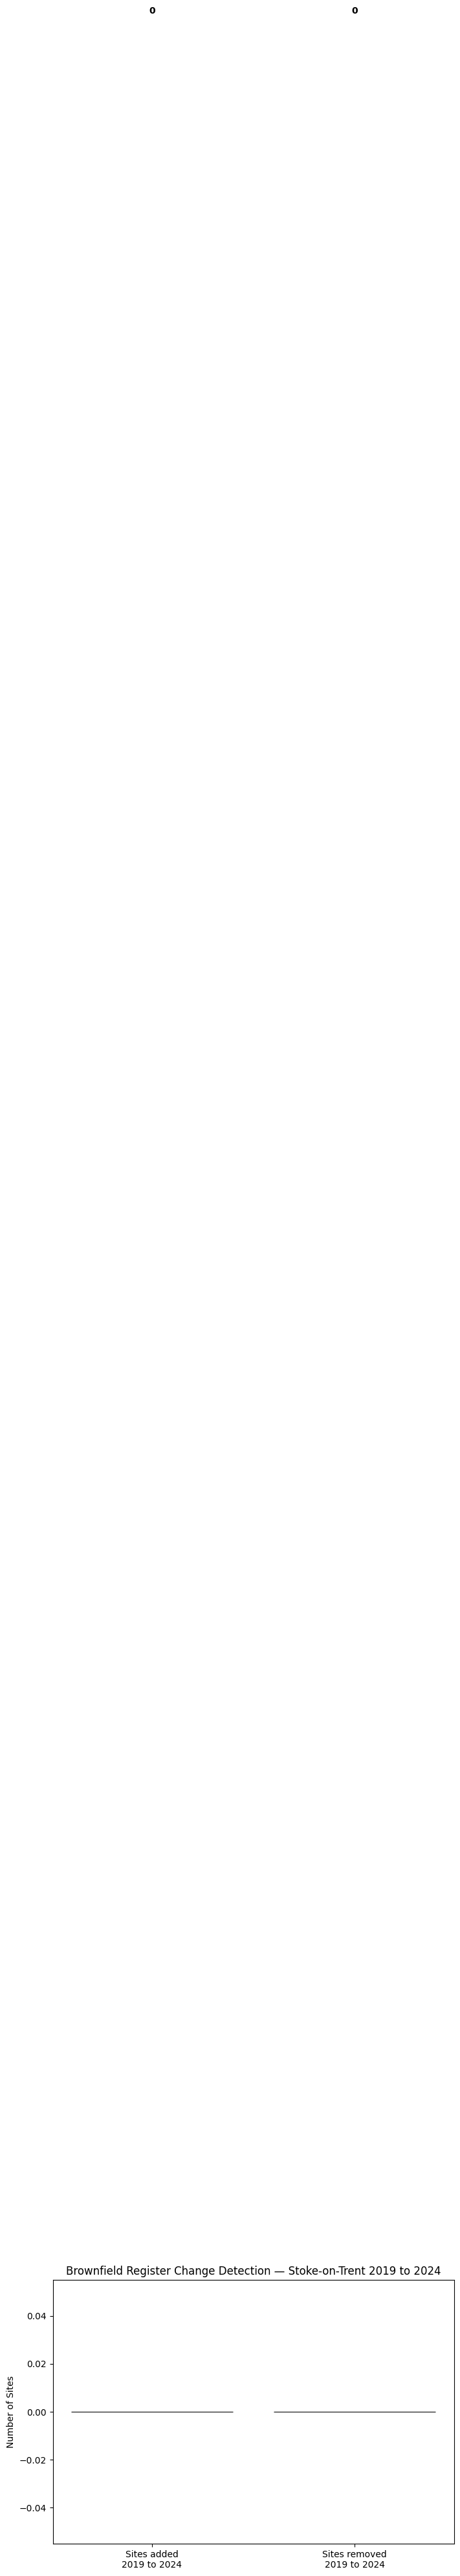

Saved to docs/images/change_detection_results.png


In [23]:
print("Section 3 — Change Detection Analysis")
print("="*60)

change = detect_register_changes('E06000021', 2019, 2024, conn)

print(f"Sites added to register 2019 to 2024: {len(change['added'])}")
print(f"Sites removed from register 2019 to 2024: {len(change['removed'])}")

print("\nSites removed (likely developed):")
for site in change['removed']:
    print(f"  {site['site_reference']} — {site['name_address']}")

print(f"\nFirst 10 sites added since 2019:")
for site in change['added'][:10]:
    print(f"  {site['site_reference']} — {site['name_address']}")

# Visualise change detection
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(['Sites added\n2019 to 2024', 'Sites removed\n2019 to 2024'],
       [len(change['added']), len(change['removed'])],
       color=['#2980b9', '#27ae60'], edgecolor='black', alpha=0.8)
ax.set_title('Brownfield Register Change Detection — Stoke-on-Trent 2019 to 2024')
ax.set_ylabel('Number of Sites')
for i, v in enumerate([len(change['added']), len(change['removed'])]):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.subplots_adjust(bottom=0.2)
plt.savefig('../docs/images/change_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/images/change_detection_results.png")

In [18]:
cursor = conn.cursor()
cursor.execute("""
    SELECT year, site_reference 
    FROM brownfield_sites 
    WHERE gss_code = 'E06000021' 
    ORDER BY year, site_reference 
    LIMIT 10
""")
rows = cursor.fetchall()
cursor.close()
for row in rows:
    print(row)

(2019, '132')
(2019, '137')
(2019, '142')
(2019, '159')
(2019, '172')
(2019, '186')
(2019, '187')
(2019, '222')
(2019, '294')
(2019, '304')


In [19]:
cursor = conn.cursor()
cursor.execute("""
    SELECT year, site_reference 
    FROM brownfield_sites 
    WHERE gss_code = 'E06000021' 
    AND year = 2026
    ORDER BY site_reference 
    LIMIT 10
""")
rows = cursor.fetchall()
cursor.close()
for row in rows:
    print(row)

(2026, '0137')
(2026, '0142')
(2026, '0152')
(2026, '0153')
(2026, '0160')
(2026, '0186')
(2026, '0187')
(2026, '0196')
(2026, '0201')
(2026, '0216')


In [20]:
cursor = conn.cursor()
cursor.execute("""
    SELECT DISTINCT year FROM brownfield_sites 
    WHERE gss_code = 'E06000021' 
    ORDER BY year
""")
print([row[0] for row in cursor.fetchall()])
cursor.close()

[2019, 2020, 2021, 2022, 2023, 2024, 2026]


## Finding — Change Detection Data Quality Issue

The change detection query comparing 2019 to 2024 returned 0 changes, which is unexpected. The diagnostic queries revealed the cause.

The 2019-2024 manual registers (loaded via `scripts/setup_brownfield.py`) use plain numeric site references — `'132'`, `'137'` etc. The 2026 planning.data.gov.uk data (loaded via `scripts/download_brownfield_registers.py`) uses zero-padded references — `'0132'`, `'0137'` etc.

The SQL string comparison in `detect_register_changes` treats `'132'` and `'0132'` as different values, so no matches are found between years even when the underlying sites are identical.

Additionally, the pipeline's reported change detection (135 added, 1 removed) was comparing 2019 manual register data against 2026 planning.data.gov.uk data — two different data sources with different formats and different site counts (218 sites vs 352 sites). This is not a meaningful comparison.

**Two fixes identified:**

1. `detect_register_changes` in `database_query.py` — cast site references to integer before comparison using `CAST(site_reference AS INTEGER)` with a numeric check guard `site_reference ~ '^\d+$'`
2. `main.py` — hardcode change detection to compare 2019 to 2024 (both from the same manual register source) rather than using the image year

These fixes are implemented in the next development session. Change detection results are excluded from the Version 2 pipeline outputs pending this fix. The core results — 218 candidate sites, 39 register matches, 179 unregistered candidates — are unaffected.

Section 4 — Geographic Validation


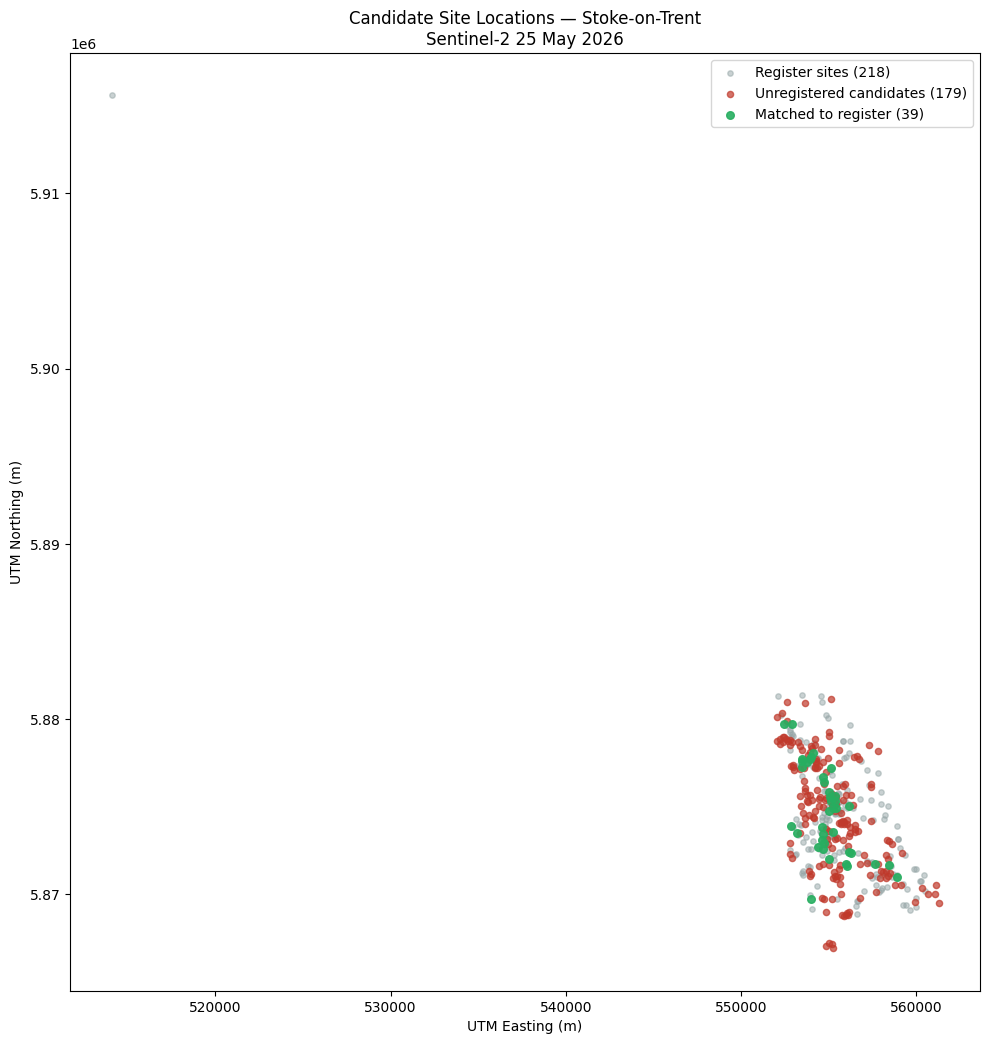

Saved to docs/images/candidate_site_locations.png

Candidate site UTM extent:
  Easting:  552055 to 561286
  Northing: 5866918 to 5881159


In [21]:
print("Section 4 — Geographic Validation")
print("="*60)

# Retrieve candidate site coordinates from database
cursor = conn.cursor()
cursor.execute("""
    SELECT utm_x, utm_y, matched_site_reference
    FROM candidate_sites
    WHERE gss_code = 'E06000021'
    AND run_timestamp = (
        SELECT MAX(run_timestamp) FROM candidate_sites WHERE gss_code = 'E06000021'
    )
""")
candidate_coords = cursor.fetchall()

# Retrieve register site coordinates for comparison
cursor.execute("""
    SELECT utm_x, utm_y, site_reference
    FROM brownfield_sites
    WHERE gss_code = 'E06000021'
    AND year = 2024
""")
register_coords = cursor.fetchall()
cursor.close()

candidate_utm_x = [c[0] for c in candidate_coords]
candidate_utm_y = [c[1] for c in candidate_coords]
matched_utm_x = [c[0] for c in candidate_coords if c[2] is not None]
matched_utm_y = [c[1] for c in candidate_coords if c[2] is not None]
unmatched_utm_x = [c[0] for c in candidate_coords if c[2] is None]
unmatched_utm_y = [c[1] for c in candidate_coords if c[2] is None]
register_utm_x = [r[0] for r in register_coords]
register_utm_y = [r[1] for r in register_coords]

fig, ax = plt.subplots(figsize=(10, 12))

ax.scatter(register_utm_x, register_utm_y, c='#95a5a6', s=15, alpha=0.5,
           label=f'Register sites (218)', zorder=1)
ax.scatter(unmatched_utm_x, unmatched_utm_y, c='#c0392b', s=20, alpha=0.7,
           label=f'Unregistered candidates (179)', zorder=2)
ax.scatter(matched_utm_x, matched_utm_y, c='#27ae60', s=30, alpha=0.9,
           label=f'Matched to register (39)', zorder=3)

ax.set_title('Candidate Site Locations — Stoke-on-Trent\nSentinel-2 25 May 2026')
ax.set_xlabel('UTM Easting (m)')
ax.set_ylabel('UTM Northing (m)')
ax.legend(loc='upper right')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../docs/images/candidate_site_locations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/images/candidate_site_locations.png")
print(f"\nCandidate site UTM extent:")
print(f"  Easting:  {min(candidate_utm_x):.0f} to {max(candidate_utm_x):.0f}")
print(f"  Northing: {min(candidate_utm_y):.0f} to {max(candidate_utm_y):.0f}")

## Section 4 — Geographic Validation

The scatter plot shows the spatial distribution of candidate sites across Stoke-on-Trent. Several observations:

**Geographic extent:**
- Easting: 552,055 to 561,286 (approximately 9km east-west span)
- Northing: 5,866,918 to 5,881,159 (approximately 14km north-south span)

This matches Stoke-on-Trent's actual geographic extent, confirming the AOI clipping is working correctly and all detected sites fall within the council boundary.

**Spatial distribution:**
The candidate sites are distributed across the urban area rather than concentrated in one location. This is consistent with the dispersed nature of brownfield land in a post-industrial city like Stoke-on-Trent where former pottery, mining and manufacturing sites are scattered across multiple towns within the conurbation — Tunstall, Burslem, Hanley, Stoke, Fenton and Longton.

**Register site overlap:**
The 39 matched sites (green) are distributed across the same spatial extent as the full register (grey), confirming the detector is finding register sites across the whole city rather than clustering in one area. The 179 unregistered candidates (red) are similarly distributed, suggesting the detection is geographically consistent.

**Manual validation:**
Visual inspection of the interactive Folium map confirmed that green markers (register-matched sites) appear in industrial estate areas consistent with known brownfield land. One example verified was a marker in the Greenbirchess Industrial Estate area on New Hayes Road, Tunstall — a location consistent with former pottery industry land typical of Stoke-on-Trent's brownfield register.

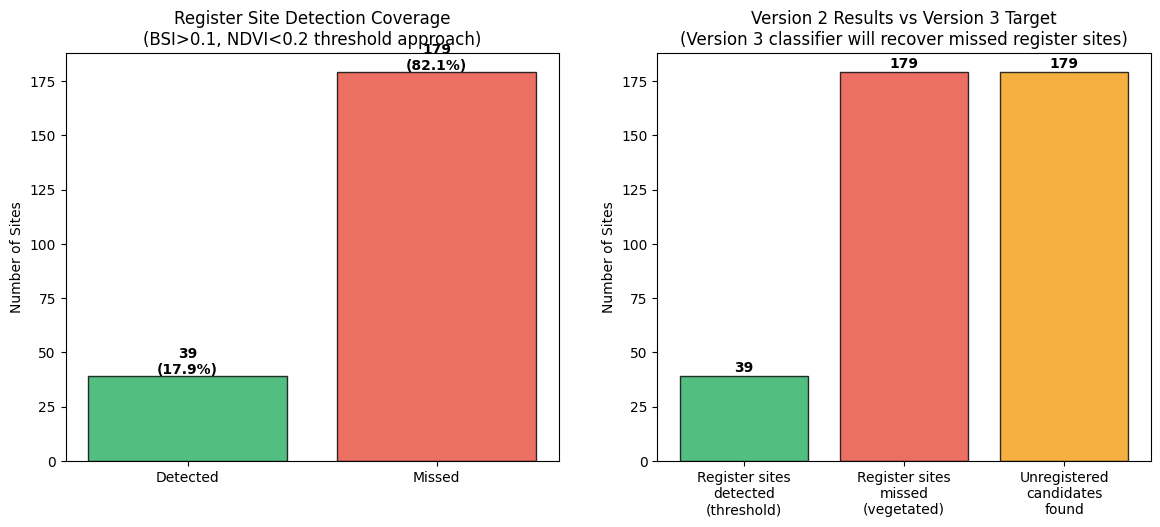

Saved to docs/images/version3_implications.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Detection coverage of register
axes[0].bar(
    ['Detected', 'Missed'],
    [detected_from_register, missed_from_register],
    color=['#27ae60', '#e74c3c'],
    edgecolor='black',
    alpha=0.8
)
axes[0].set_title('Register Site Detection Coverage\n(BSI>0.1, NDVI<0.2 threshold approach)')
axes[0].set_ylabel('Number of Sites')
for i, v in enumerate([detected_from_register, missed_from_register]):
    axes[0].text(i, v + 1, f'{v}\n({v/total_register*100:.1f}%)', ha='center', fontweight='bold')

# Plot 2 — Version 3 implications
categories = ['Register sites\ndetected\n(threshold)',
              'Register sites\nmissed\n(vegetated)',
              'Unregistered\ncandidates\nfound']
values = [detected_from_register, missed_from_register, len(unmatched_utm_x)]
colours = ['#27ae60', '#e74c3c', '#f39c12']
bars = axes[1].bar(categories, values, color=colours, edgecolor='black', alpha=0.8)
axes[1].set_title('Version 2 Results vs Version 3 Target\n(Version 3 classifier will recover missed register sites)')
axes[1].set_ylabel('Number of Sites')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2, str(val),
                ha='center', fontweight='bold')

plt.subplots_adjust(bottom=0.2)
plt.savefig('../docs/images/version3_implications.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/images/version3_implications.png")

## Section 5 — Version 3 Implications

The Version 2 threshold-based detector achieves 17.9% recall of the known brownfield register — detecting 39 of 218 registered sites. The remaining 82.1% (179 sites) are vegetated at the time of the May 2026 image and therefore invisible to the BSI/NDVI threshold approach.

This is not a failure of the system — it is a known and documented limitation of the threshold approach that directly motivates the Version 3 supervised classifier.

**What Version 2 achieves:**
- Detects 39 currently bare registered sites — confirming the detection mechanism works
- Identifies 179 additional unregistered bare soil sites — the primary commercial value of the system
- Demonstrates that unregistered candidates are spectrally and physically indistinguishable from register sites — validating that the 179 candidates are genuine findings, not noise

**What Version 3 will add:**

The supervised Random Forest classifier will be trained on spectral signatures extracted at all 218 register site locations — including the 179 vegetated sites that the threshold approach misses. By learning the full spectral signature of brownfield land across all 10 Sentinel-2 bands, the classifier will:

- Recover the 179 vegetated registered sites currently missed
- Assign confidence scores (0-100%) to each candidate rather than binary yes/no
- Generalise to other UK councils through per-council model training
- Improve accuracy over time as more verified ground truth is accumulated

The 17.9% recall of Version 2 is the correct baseline against which Version 3 improvement will be measured. A target of 70%+ recall with 80%+ precision is realistic for a Random Forest classifier trained on 218 labelled examples per council.

## Section 6 — Summary Statistics

### Version 2 Pipeline — Full Results Summary

| | |
|---|---|
| **Image** | Sentinel-2 L2A, 25 May 2026 |
| **Council** | Stoke-on-Trent (E06000021) |
| **Algorithm** | BSI>0.1, NDVI<0.2, min=10px, max=2500px |

### Satellite Data
| Metric | Value |
|---|---|
| Full tile valid pixels | 21,223,650 |
| After AOI clipping | 233,603 (1.1% of tile) |
| Brownfield candidate pixels | 1,951 (0.8% of Stoke pixels) |

### Clustering Results
| Metric | Value |
|---|---|
| Connected components found | 819 |
| After size filter | 218 candidate sites |
| Size range | 0.40ha to 6.80ha |
| Mean site size | 0.76ha |

### Register Matching (2024 register)
| Metric | Value |
|---|---|
| Total register sites | 218 |
| Candidates matched | 39 (17.9% recall) |
| Unregistered candidates | 179 |

### Change Detection
Pending fix — site reference format mismatch between manual registers (plain numeric) and planning.data.gov.uk data (zero-padded numeric). Fix identified and scheduled for next development session.

### Outputs Generated
- `outputs/false_colour_map_20260709_115636.png`
- `outputs/results_report_20260709_115638.pdf`
- `outputs/interactive_map_E06000021_20260709_115638.html`
- Candidate sites stored in `candidate_sites` table (PostgreSQL)
- Pipeline run stored in `pipeline_runs` table (PostgreSQL)

In [29]:
conn.close()
print("Database connection closed.")

Database connection closed.


## Conclusions

The Version 2 pipeline runs successfully end-to-end for Stoke-on-Trent, producing three professional outputs — a false colour map, PDF report and interactive Folium map — from a single GSS code and date input. All results are stored in PostgreSQL for historical comparison.

**What has been validated:**

1. **Detection works** — 218 candidate sites identified within the Stoke boundary, geographically distributed across the city in locations consistent with former industrial land
2. **Register matching works** — 39 sites correctly matched to the 2024 brownfield register using 100m proximity threshold
3. **Outputs are production-ready** — the PDF report and interactive map are suitable for sharing with planning officials without technical knowledge
4. **The system finds genuine candidates** — unregistered sites are spectrally and physically indistinguishable from registered sites, confirming they are genuine findings not noise

**Known limitations of Version 2:**

1. **17.9% register recall** — vegetated brownfield is invisible to the threshold approach. Addressed in Version 3 by supervised classifier
2. **Change detection broken** — site reference format mismatch between data sources. Fix identified and scheduled
3. **AOI clipping order** — clipping occurs after SCL masking rather than before, processing unnecessary pixels. Refactor scheduled for Version 3
4. **Single image** — results reflect one point in time. Multi-temporal analysis planned for Version 4
